In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

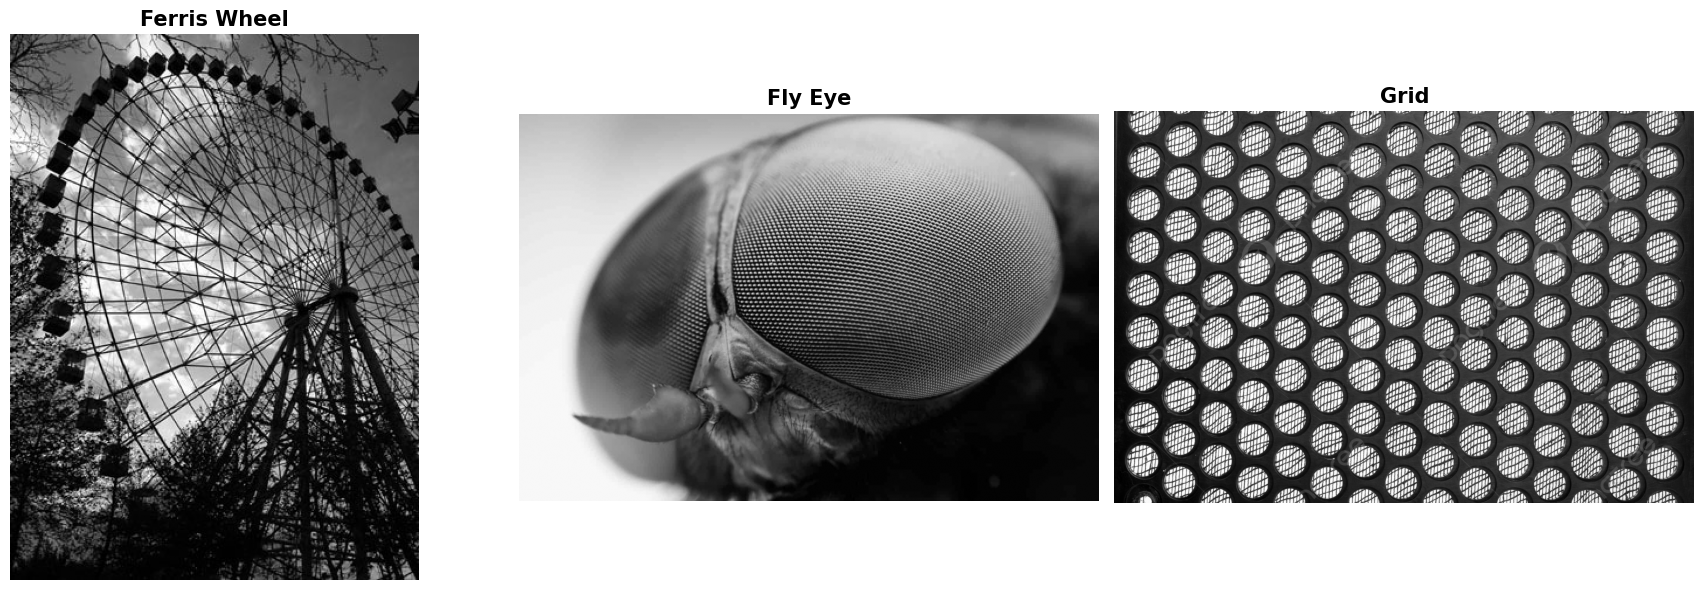

In [9]:
FerrisWheel = "./Input_Images/FerrisWheel.jpg"
FerrisWheel_8bit = cv2.imread(FerrisWheel, cv2.IMREAD_GRAYSCALE)

FlyEye = "./Input_Images/FlyEye.jpg"
FlyEye_8bit = cv2.imread(FlyEye, cv2.IMREAD_GRAYSCALE)

Grid = "./Input_Images/Grid.jpg"
Grid_8bit = cv2.imread(Grid, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

images = [FerrisWheel_8bit, FlyEye_8bit, Grid_8bit]
titles = ["Ferris Wheel", "Fly Eye", "Grid"]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [10]:
for i ,img in enumerate(images):
    print(titles[i])
    
    F = np.fft.fft2(img)
    F_shifted = np.fft.fftshift(F)

    M, N = F_shifted.shape

    E_total = np.sum(np.abs(F_shifted)**2)

    r4 = 4
    row_start_4 = M // 2 - M // (2 * r4)
    row_end_4   = M // 2 + M // (2 * r4)
    col_start_4 = N // 2 - N // (2 * r4)
    col_end_4   = N // 2 + N // (2 * r4)

    center_box_4 = F_shifted[row_start_4:row_end_4, col_start_4:col_end_4]
    E_main_4 = np.sum(np.abs(center_box_4)**2)

    E_aliasing_4 = E_total - E_main_4
    ratio_4 = E_main_4 / E_aliasing_4
    print(f"Energy 4: {ratio_4}")
    
    r16 = 16
    row_start_16 = M // 2 - M // (2 * r16)
    row_end_16   = M // 2 + M // (2 * r16)
    col_start_16 = N // 2 - N // (2 * r16)
    col_end_16   = N // 2 + N // (2 * r16)

    center_box_16 = F_shifted[row_start_16:row_end_16, col_start_16:col_end_16]
    E_main_16 = np.sum(np.abs(center_box_16)**2)

    E_aliasing_16 = E_total - E_main_16
    ratio_16 = E_main_16 / E_aliasing_16
    print(f"Energy 16: {ratio_16}")
    print("----------------")


Ferris Wheel
Energy 4: 10.770069088534113
Energy 16: 5.082636796408612
----------------
Fly Eye
Energy 4: 154.18637263236016
Energy 16: 22.897168091153866
----------------
Grid
Energy 4: 8.127307960344886
Energy 16: 4.405067633350486
----------------


In [11]:
rates = [4, 16]

for title ,img in enumerate(images):
    print(titles[title])
    
    original_height, original_width = img.shape
    
    for r in rates:
        downsampled_img = img[::r, ::r]
        
        upsampled_nn = cv2.resize(downsampled_img,(original_width, original_height),interpolation=cv2.INTER_NEAREST)
        
        upsampled_bl = cv2.resize(downsampled_img,(original_width, original_height),interpolation=cv2.INTER_LINEAR)
        
        filename_nn = f"{title}_Rate{r}_Nearest.jpg"
        filename_bl = f"{title}_Rate{r}_Bilinear.jpg"
        
        cv2.imwrite(os.path.join("./Output_Images/Part_2", filename_nn), upsampled_nn)
        cv2.imwrite(os.path.join("./Output_Images/Part_2", filename_bl), upsampled_bl)

Ferris Wheel
Fly Eye
Grid


In [12]:
kernel_1d = np.array([0.25, 0.5, 0.25])

for title ,img in enumerate(images):
    print(titles[title])
    
    original_height, original_width = img.shape
    filtered_img = cv2.sepFilter2D(img, -1, kernel_1d, kernel_1d)
    
    down4_img = filtered_img[::4, ::4]
    filtered_down4 = cv2.sepFilter2D(down4_img, -1, kernel_1d, kernel_1d)
    
    down16_img = filtered_down4[::4, ::4]
    
    up4_nn = cv2.resize(down4_img, (original_width, original_height), interpolation=cv2.INTER_NEAREST)
    up4_bl = cv2.resize(down4_img, (original_width, original_height), interpolation=cv2.INTER_LINEAR)
    
    up16_nn = cv2.resize(down16_img, (original_width, original_height), interpolation=cv2.INTER_NEAREST)
    up16_bl = cv2.resize(down16_img, (original_width, original_height), interpolation=cv2.INTER_LINEAR)
    
    cv2.imwrite(f"./Output_Images/Part_3/{title}_Rate4_Nearest.jpg", up4_nn)
    cv2.imwrite(f"./Output_Images/Part_3/{title}_Rate4_Bilinear.jpg", up4_bl)
    cv2.imwrite(f"./Output_Images/Part_3/{title}_Rate16_Nearest.jpg", up16_nn)
    cv2.imwrite(f"./Output_Images/Part_3/{title}_Rate16_Bilinear.jpg", up16_bl)

Ferris Wheel
Fly Eye
Grid


In [13]:
kernel_1d_new = np.array([0.0267, 0.0169, 0.0782, 0.2669, 0.6029, 0.2669, 0.0782, 0.0169, 0.0267])


for title ,img in enumerate(images):
    print(titles[title])
    
    original_height, original_width = img.shape
    filtered_img = cv2.sepFilter2D(img, -1, kernel_1d_new, kernel_1d_new)
    
    down4_img = filtered_img[::4, ::4]
    filtered_down4 = cv2.sepFilter2D(down4_img, -1, kernel_1d_new, kernel_1d_new)
    
    down16_img = filtered_down4[::4, ::4]
    
    up4_nn = cv2.resize(down4_img, (original_width, original_height), interpolation=cv2.INTER_NEAREST)
    up4_bl = cv2.resize(down4_img, (original_width, original_height), interpolation=cv2.INTER_LINEAR)
    
    up16_nn = cv2.resize(down16_img, (original_width, original_height), interpolation=cv2.INTER_NEAREST)
    up16_bl = cv2.resize(down16_img, (original_width, original_height), interpolation=cv2.INTER_LINEAR)
    
    cv2.imwrite(f"./Output_Images/Part_4/{title}_Rate4_Nearest.jpg", up4_nn)
    cv2.imwrite(f"./Output_Images/Part_4/{title}_Rate4_Bilinear.jpg", up4_bl)
    cv2.imwrite(f"./Output_Images/Part_4/{title}_Rate16_Nearest.jpg", up16_nn)
    cv2.imwrite(f"./Output_Images/Part_4/{title}_Rate16_Bilinear.jpg", up16_bl)

Ferris Wheel
Fly Eye
Grid
